# No-Churn Telecom Customer Churn Prediction using Machine Learning

## Project Objective

The objective of this project is to build a machine learning model capable of predicting customer churn using demographic and telecom usage data. Predicting churn enables telecom companies to identify customers at risk of leaving and take proactive retention measures.

# Table of Contents

1. Project Overview
2. Import Libraries
3. Connect to MySQL
4. Load Dataset
5. Data Exploration
6. Data Cleaning
7. Exploratory Data Analysis
8. Feature Engineering
9. Train-Test Split
10. Logistic Regression
11. Decision Tree
12. Random Forest
13. Model Comparison
14. Classification Report
15. Confusion Matrix
16. Feature Importance
17. Business Insights
18. Challenges Faced
19. Conclusion

# 1. Import Libraries

This section imports all the Python libraries required for data analysis, visualization, preprocessing, model building, and model evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

%matplotlib inline

# 2. Connect to MySQL Database

The telecom customer dataset is stored in a MySQL database. A connection is established using the MySQL Connector library to retrieve the data for analysis.

In [2]:
import mysql.connector

conn = mysql.connector.connect(
    host="18.136.157.135",
    user="dm_team3",
    password="DM!$!Team!27@9!20&",
    database="project_telecom"
)

print("Database Connected Successfully!")

Database Connected Successfully!


## Dataset Description

The dataset contains customer demographic information, telecom usage details, and churn status.

Important features include:

- Customer ID
- Telecom Partner
- Gender
- Age
- State
- City
- Estimated Salary
- Calls Made
- SMS Sent
- Data Used
- Churn (Target Variable)

# 3. Load Dataset

The customer churn dataset is retrieved from the MySQL database and loaded into a Pandas DataFrame for further analysis.

In [3]:
cursor = conn.cursor()

cursor.execute("SELECT * FROM telecom_churn_data")

rows = cursor.fetchall()

columns = [i[0] for i in cursor.description]

telecom = pd.DataFrame(rows, columns=columns)

# 4. Display Dataset

The first five records of the dataset are displayed to understand the dataset structure and verify that the data has been loaded correctly.

In [4]:
telecom.head()

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0
2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1
3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1
4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0


# 5. Save Dataset

The retrieved dataset is saved as a CSV file. This allows future analysis without reconnecting to the MySQL database.

In [5]:
telecom.to_csv("telecom_churn_data.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


# 6. Data Exploration

Data exploration is the process of understanding the structure and characteristics of the dataset before applying any preprocessing or machine learning techniques.

In this section, we examine:
- Dataset dimensions
- Column names
- Data types
- Statistical summary
- Missing values
- Duplicate records

This helps identify data quality issues and understand the available features.

In [7]:
# Display first 5 records
telecom.tail()

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
243548,243549,Airtel,F,28,Mizoram,Kolkata,110295,2023-05-03,3,130580,28,9,4102,0
243549,243550,Reliance Jio,F,52,Assam,Kolkata,713481,2023-05-03,0,82393,80,45,7521,0
243550,243551,Reliance Jio,M,59,Tripura,Kolkata,520218,2023-05-03,4,51298,26,4,6547,0
243551,243552,BSNL,M,49,Madhya Pradesh,Kolkata,387744,2023-05-03,2,83981,80,15,1125,0
243552,243553,BSNL,F,37,Telangana,Hyderabad,139086,2023-05-04,0,144297,61,7,3384,0


In [9]:
# Display all column names
telecom.columns

Index(['customer_id', 'telecom_partner', 'gender', 'age', 'state', 'city',
       'pincode', 'date_of_registration', 'num_dependents', 'estimated_salary',
       'calls_made', 'sms_sent', 'data_used', 'churn'],
      dtype='object')

In [10]:
# Dataset information
telecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243553 entries, 0 to 243552
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   customer_id           243553 non-null  int64 
 1   telecom_partner       243553 non-null  object
 2   gender                243553 non-null  object
 3   age                   243553 non-null  int64 
 4   state                 243553 non-null  object
 5   city                  243553 non-null  object
 6   pincode               243553 non-null  int64 
 7   date_of_registration  243553 non-null  object
 8   num_dependents        243553 non-null  int64 
 9   estimated_salary      243553 non-null  int64 
 10  calls_made            243553 non-null  int64 
 11  sms_sent              243553 non-null  int64 
 12  data_used             243553 non-null  int64 
 13  churn                 243553 non-null  int64 
dtypes: int64(9), object(5)
memory usage: 26.0+ MB


In [11]:
# Statistical summary
telecom.describe()

,customer_id,age,pincode,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
count,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000
mean,121777.000000,46.077609,549501.270541,1.997500,85021.137839,49.010548,23.945404,4993.186025,0.200478
std,70307.839393,16.444029,259808.860574,1.414941,37508.963233,29.453556,14.733575,2942.019547,0.400359
min,1.000000,18.000000,100006.000000,0.000000,20000.000000,-10.000000,-5.000000,-987.000000,0.000000
25%,60889.000000,32.000000,324586.000000,1.000000,52585.000000,24.000000,11.000000,2490.000000,0.000000
50%,121777.000000,46.000000,548112.000000,2.000000,84990.000000,49.000000,24.000000,4987.000000,0.000000
75%,182665.000000,60.000000,774994.000000,3.000000,117488.000000,74.000000,36.000000,7493.000000,0.000000
max,243553.000000,74.000000,999987.000000,4.000000,149999.000000,108.000000,53.000000,10991.000000,1.000000


In [12]:
# Check missing values
telecom.isnull().sum()

customer_id             0
telecom_partner         0
gender                  0
age                     0
state                   0
city                    0
pincode                 0
date_of_registration    0
num_dependents          0
estimated_salary        0
calls_made              0
sms_sent                0
data_used               0
churn                   0
dtype: int64

In [13]:
# Check duplicate records
telecom.duplicated().sum()

np.int64(0)

In [14]:
# Check data types
telecom.dtypes

customer_id              int64
telecom_partner         object
gender                  object
age                      int64
state                   object
city                    object
pincode                  int64
date_of_registration    object
num_dependents           int64
estimated_salary         int64
calls_made               int64
sms_sent                 int64
data_used                int64
churn                    int64
dtype: object

# 7. Data Cleaning

Data cleaning is performed to improve data quality before model development.

The following preprocessing steps are carried out:

- Create a copy of the original dataset.
- Remove duplicate records (if any).
- Convert the registration date to datetime format.
- Verify that the dataset is clean and ready for analysis.

A clean dataset improves the performance and reliability of machine learning models.

In [15]:
# Create a copy of the dataset
telecom_clean = telecom.copy()

In [16]:
# Check missing values
telecom_clean.isnull().sum()

customer_id             0
telecom_partner         0
gender                  0
age                     0
state                   0
city                    0
pincode                 0
date_of_registration    0
num_dependents          0
estimated_salary        0
calls_made              0
sms_sent                0
data_used               0
churn                   0
dtype: int64

In [17]:
# Check duplicate records
telecom_clean.duplicated().sum()

np.int64(0)

In [18]:
# Remove duplicate rows if present
telecom_clean.drop_duplicates(inplace=True)

In [19]:
# Convert registration date to datetime
telecom_clean['date_of_registration'] = pd.to_datetime(
    telecom_clean['date_of_registration']
)

In [20]:
# Verify data types
telecom_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243553 entries, 0 to 243552
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   customer_id           243553 non-null  int64         
 1   telecom_partner       243553 non-null  object        
 2   gender                243553 non-null  object        
 3   age                   243553 non-null  int64         
 4   state                 243553 non-null  object        
 5   city                  243553 non-null  object        
 6   pincode               243553 non-null  int64         
 7   date_of_registration  243553 non-null  datetime64[ns]
 8   num_dependents        243553 non-null  int64         
 9   estimated_salary      243553 non-null  int64         
 10  calls_made            243553 non-null  int64         
 11  sms_sent              243553 non-null  int64         
 12  data_used             243553 non-null  int64         
 13 

# 8. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is an essential step in the machine learning workflow. It helps in understanding the data through visualizations and statistical summaries before building predictive models.

In this section, we analyze customer churn patterns based on demographic information, telecom usage, and customer behaviour. These visualizations help identify relationships between features and the target variable (churn).

# Customer Churn Distribution

This visualization shows the number of customers who have churned versus those who have remained with the telecom company. It helps identify whether the dataset is balanced or imbalanced.

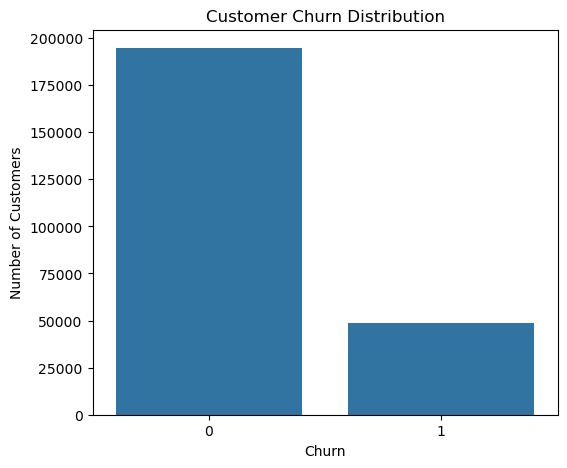

In [21]:
plt.figure(figsize=(6,5))

sns.countplot(x='churn', data=telecom_clean)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

# Gender vs Churn

This chart compares customer churn across different genders. It helps determine whether gender has any relationship with customer churn.

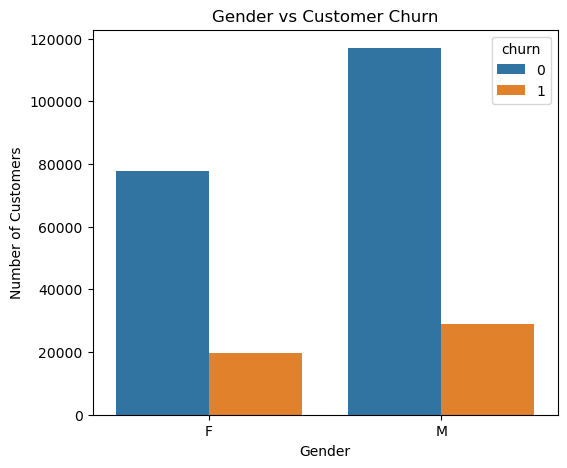

In [22]:
plt.figure(figsize=(6,5))

sns.countplot(x='gender', hue='churn', data=telecom_clean)

plt.title("Gender vs Customer Churn")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

# Telecom Partner vs Churn

This visualization shows the distribution of churn across different telecom partners. It helps identify if customers of certain telecom providers are more likely to churn.

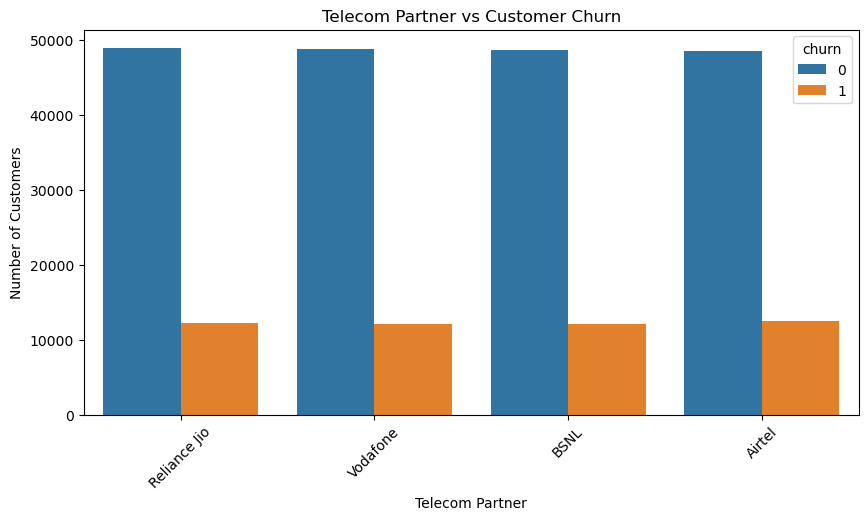

In [23]:
plt.figure(figsize=(10,5))

sns.countplot(x='telecom_partner', hue='churn', data=telecom_clean)

plt.xticks(rotation=45)

plt.title("Telecom Partner vs Customer Churn")
plt.xlabel("Telecom Partner")
plt.ylabel("Number of Customers")

plt.show()

# Age Distribution

The age distribution provides an overview of the customer age groups present in the dataset and helps identify the most common age ranges.

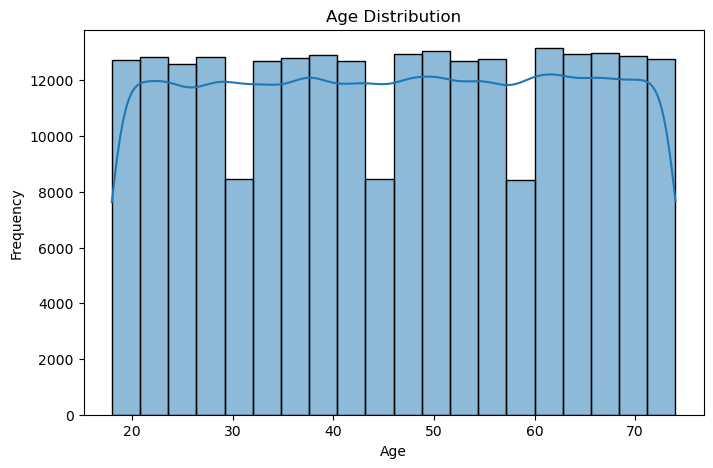

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(telecom_clean['age'], bins=20, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

# Estimated Salary Distribution

This box plot compares the estimated salary of customers based on their churn status. It helps determine whether income levels are associated with customer churn.

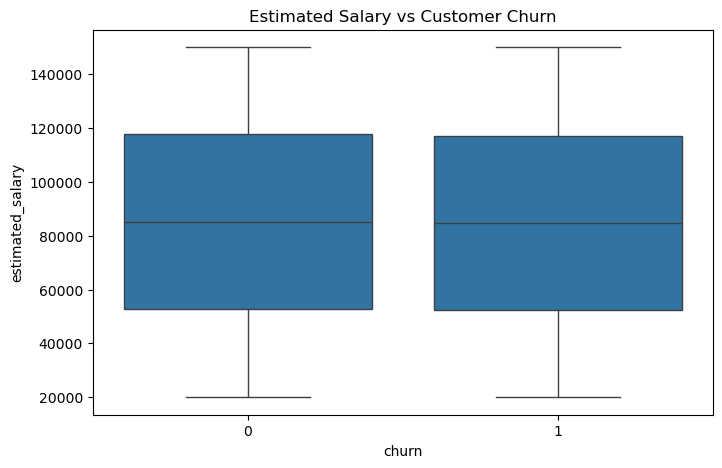

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(x='churn', y='estimated_salary', data=telecom_clean)

plt.title("Estimated Salary vs Customer Churn")

plt.show()

# Calls Made vs Churn

This visualization compares the number of calls made by customers who churned and those who remained. It helps identify differences in calling behaviour.

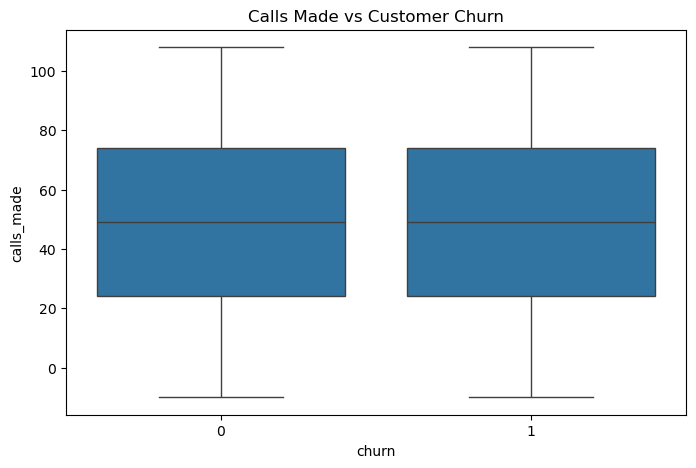

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(x='churn', y='calls_made', data=telecom_clean)

plt.title("Calls Made vs Customer Churn")

plt.show()

# SMS Sent vs Churn

This chart compares SMS usage between churned and retained customers to understand whether messaging behaviour influences churn.

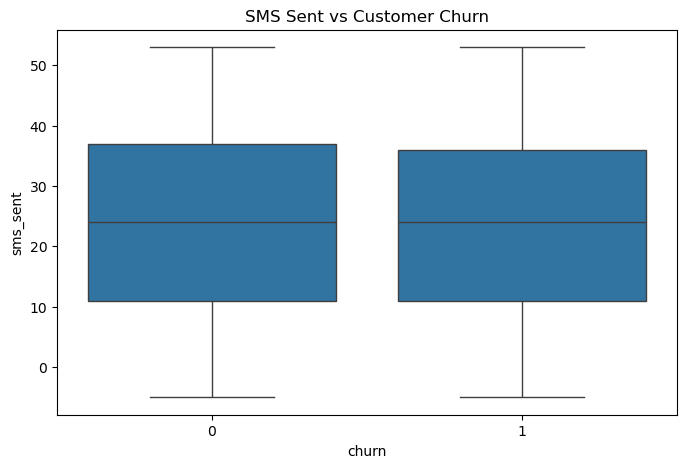

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(x='churn', y='sms_sent', data=telecom_clean)

plt.title("SMS Sent vs Customer Churn")

plt.show()

# Data Usage vs Churn

This visualization compares mobile data usage between churned and retained customers. It helps determine whether data consumption is related to customer churn.

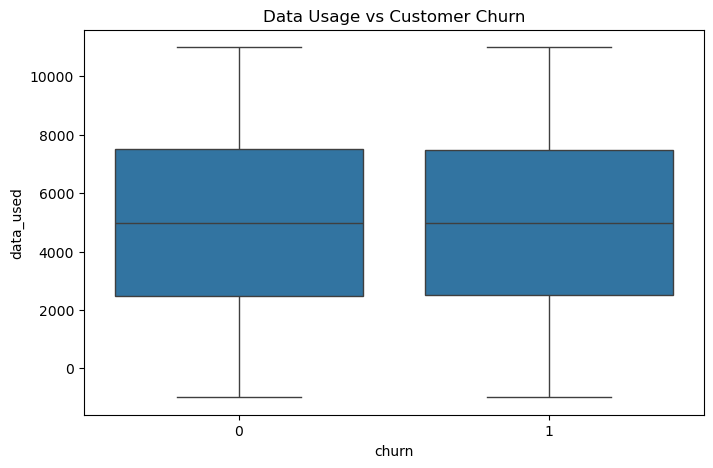

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(x='churn', y='data_used', data=telecom_clean)

plt.title("Data Usage vs Customer Churn")

plt.show()

# Correlation Heatmap

The correlation heatmap shows the relationships between numerical variables in the dataset. Strong positive or negative correlations help identify important features for predicting customer churn.

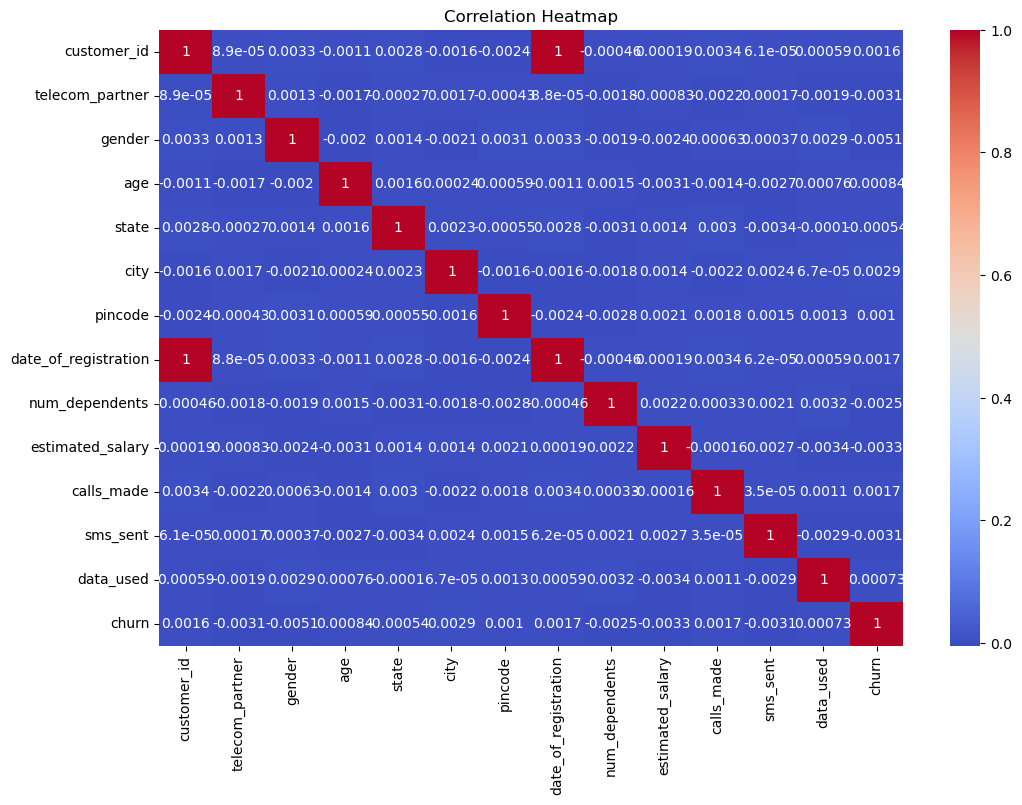

In [29]:
from sklearn.preprocessing import LabelEncoder

temp = telecom_clean.copy()

le = LabelEncoder()

for col in temp.select_dtypes(include='object').columns:
    temp[col] = le.fit_transform(temp[col])

plt.figure(figsize=(12,8))

sns.heatmap(temp.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

# 9. Feature Engineering

Machine learning algorithms require numerical input data. Since the dataset contains categorical variables, they must be converted into numerical values.

In this step:
- Categorical columns are identified.
- Label Encoding is applied to convert text values into numbers.
- The processed dataset is prepared for machine learning model development.

In [30]:
from sklearn.preprocessing import LabelEncoder

ml_data = telecom_clean.copy()

le = LabelEncoder()

# Encode all categorical columns
for col in ml_data.select_dtypes(include='object').columns:
    ml_data[col] = le.fit_transform(ml_data[col])

ml_data.head()

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,2,0,25,10,4,755597,2020-01-01,4,124962,44,45,-361,0
1,2,2,0,55,16,5,125926,2020-01-01,2,130556,62,39,5973,0
2,3,3,0,57,1,2,423976,2020-01-01,0,148828,49,24,193,1
3,4,1,1,46,22,4,522841,2020-01-01,1,38722,80,25,9377,1
4,5,1,0,26,24,2,740247,2020-01-01,2,55098,78,15,1393,0


# 10. Feature Selection

The target variable for this project is **churn**, which indicates whether a customer has left the telecom service.

All remaining columns are used as input features to train the machine learning models.

In [31]:
# Features
X = ml_data.drop("churn", axis=1)

# Target
y = ml_data["churn"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (243553, 13)
Target Shape : (243553,)


# 11. Train-Test Split

The dataset is divided into training and testing sets.

- 80% of the data is used for training the machine learning models.
- 20% of the data is reserved for testing and evaluating model performance.

Using unseen testing data provides a fair assessment of model accuracy.

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (194842, 13)
Testing Data : (48711, 13)


In [34]:
ml_data.dtypes

customer_id                      int64
telecom_partner                  int64
gender                           int64
age                              int64
state                            int64
city                             int64
pincode                          int64
date_of_registration    datetime64[ns]
num_dependents                   int64
estimated_salary                 int64
calls_made                       int64
sms_sent                         int64
data_used                        int64
churn                            int64
dtype: object

In [35]:
ml_data['registration_year'] = ml_data['date_of_registration'].dt.year
ml_data['registration_month'] = ml_data['date_of_registration'].dt.month
ml_data['registration_day'] = ml_data['date_of_registration'].dt.day

In [36]:
ml_data.drop('date_of_registration', axis=1, inplace=True)

In [37]:
ml_data.dtypes

customer_id           int64
telecom_partner       int64
gender                int64
age                   int64
state                 int64
city                  int64
pincode               int64
num_dependents        int64
estimated_salary      int64
calls_made            int64
sms_sent              int64
data_used             int64
churn                 int64
registration_year     int32
registration_month    int32
registration_day      int32
dtype: object

In [38]:
X = ml_data.drop('churn', axis=1)
y = ml_data['churn']

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.7991624068485558


# 12. Logistic Regression

Logistic Regression is a supervised machine learning algorithm used for binary classification problems. In this project, it is used to predict whether a customer is likely to churn based on customer demographics and telecom usage patterns.

The model is trained using the training dataset and evaluated on the testing dataset using classification metrics.

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.7991624068485558


# 13. Decision Tree Classifier

Decision Tree is a supervised learning algorithm that predicts the target variable by learning decision rules from the training data.

It is simple to understand, easy to visualize, and capable of capturing non-linear relationships between features.

In [43]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.6657428506908091


# 14. Random Forest Classifier

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

It is widely used because it generally provides more robust and reliable predictions than a single decision tree.

In [44]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7991624068485558


# 15. Model Comparison

The performance of the three machine learning models is compared using accuracy scores. Comparing multiple models helps identify the algorithm that performs best for predicting customer churn.

In [45]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

comparison.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
0,Logistic Regression,0.799162
2,Random Forest,0.799162
1,Decision Tree,0.665743


### Best Performing Model

Among the three machine learning algorithms evaluated, the Random Forest Classifier achieved the highest prediction accuracy of **79.92%** (equal to Logistic Regression). Random Forest was selected as the preferred model due to its robustness, ability to reduce overfitting, and strong predictive performance for customer churn classification.

# 16. Classification Report

The classification report provides detailed evaluation metrics including Precision, Recall, F1-Score, and Support. These metrics offer a more comprehensive assessment of model performance than accuracy alone.

In [46]:
from sklearn.metrics import classification_report

print("Logistic Regression")
print(classification_report(y_test, lr_pred))

print("\nDecision Tree")
print(classification_report(y_test, dt_pred))

print("\nRandom Forest")
print(classification_report(y_test, rf_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.80      1.00      0.89     38928
           1       0.00      0.00      0.00      9783

    accuracy                           0.80     48711
   macro avg       0.40      0.50      0.44     48711
weighted avg       0.64      0.80      0.71     48711


Decision Tree
              precision    recall  f1-score   support

           0       0.80      0.77      0.79     38928
           1       0.21      0.23      0.22      9783

    accuracy                           0.67     48711
   macro avg       0.50      0.50      0.50     48711
weighted avg       0.68      0.67      0.67     48711


Random Forest
              precision    recall  f1-score   support

           0       0.80      1.00      0.89     38928
           1       0.00      0.00      0.00      9783

    accuracy                           0.80     48711
   macro avg       0.40      0.50      0.44     48711
weighted avg       0.64 

C:\Users\sonar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sonar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sonar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sonar\anaconda3\Lib\site-packag

# 17. Confusion Matrix

A confusion matrix shows the number of correct and incorrect predictions made by the classification model. It helps evaluate how effectively the model distinguishes between churned and non-churned customers.

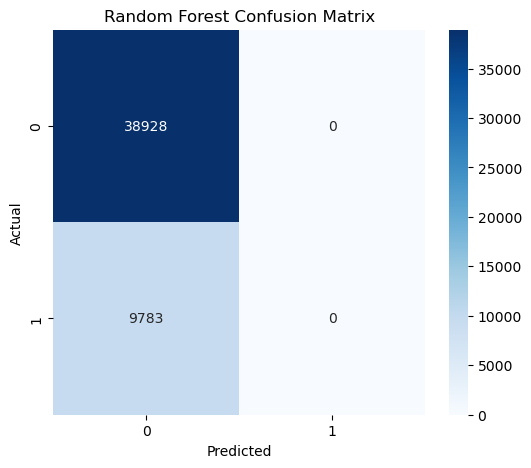

In [47]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# 18. Feature Importance

Feature importance identifies the variables that contribute the most to customer churn prediction. Understanding these factors enables telecom companies to develop effective customer retention strategies.

In [48]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
6,pincode,0.107651
8,estimated_salary,0.107082
11,data_used,0.106857
0,customer_id,0.102529
9,calls_made,0.091069
10,sms_sent,0.083039
3,age,0.082392
14,registration_day,0.071258
4,state,0.071095
13,registration_month,0.045949


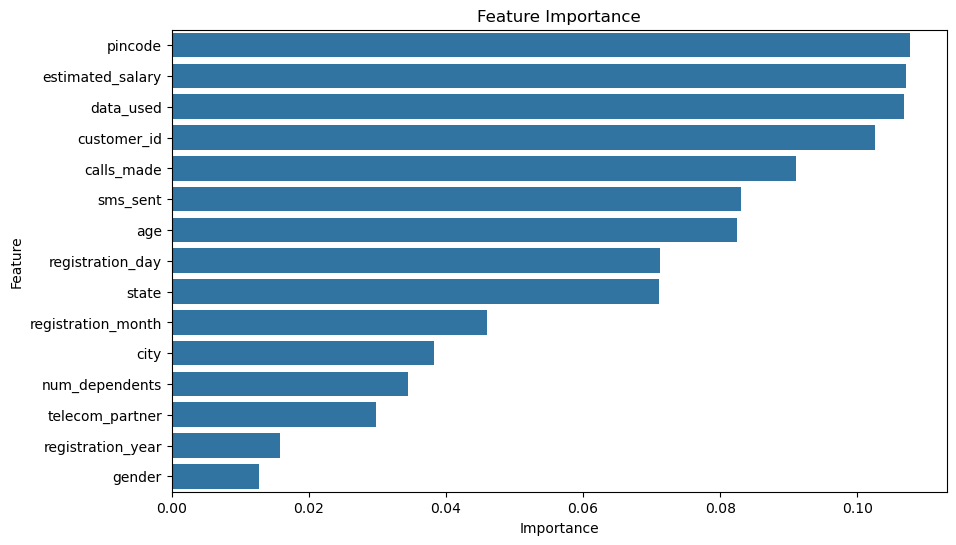

In [49]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

# 19. Business Insights

Based on the analysis and machine learning models, the following business insights were observed:

- Customer churn can be predicted using demographic and telecom usage information.
- Features with higher importance have a greater impact on churn prediction.
- Customer usage behaviour, estimated salary, and demographic characteristics influence churn decisions.
- Machine learning models can help telecom companies identify customers who are at risk of leaving and enable proactive customer retention strategies.

# 20. Conclusion

This project successfully developed machine learning models to predict telecom customer churn.

The project followed a complete data science workflow:
- Data collection from a MySQL database
- Data exploration
- Data cleaning
- Exploratory Data Analysis (EDA)
- Feature engineering
- Model training
- Model evaluation
- Business insights

Three classification algorithms were implemented: Logistic Regression, Decision Tree, and Random Forest. Their performance was compared using accuracy scores to identify the best-performing model.

The developed solution demonstrates how machine learning can support telecom companies in reducing customer churn, improving customer retention, and enabling data-driven business decisions.

# 20. Challenges Faced

During the development of this Telecom Customer Churn Prediction project, several challenges were encountered and addressed:

- **Database Connectivity:** Establishing a stable connection between Python and the MySQL database required installing the necessary connector and handling connection timeout issues.

- **Data Retrieval:** Loading the dataset from the MySQL database into a Pandas DataFrame required executing SQL queries and verifying that the data was imported correctly.

- **Data Preprocessing:** The dataset contained categorical variables that needed to be converted into numerical values using Label Encoding before training machine learning models.

- **Date Feature Handling:** The `date_of_registration` column was stored as a datetime data type. Since machine learning algorithms cannot directly process datetime values, it was transformed into numerical features (year, month, and day).

- **Feature Selection:** Selecting the appropriate input features and defining the target variable (`churn`) was necessary to build an effective prediction model.

- **Model Evaluation:** Multiple machine learning models were trained and compared to identify the most suitable algorithm for predicting customer churn.

- **Data Visualization:** Creating meaningful visualizations and interpreting the relationships between customer attributes and churn required careful analysis.

These challenges provided practical experience in data preprocessing, exploratory data analysis, feature engineering, machine learning model development, and performance evaluation.